# PSM Analysis: Morning vs Evening Response Time on Q1 (Hard) Cards

**Question:** Does reviewing in the morning (06:00–12:00) cause *faster* or *slower* response times than evening (18:00–24:00), among the hardest cards (ease factor ≤ 2.65, bottom quartile)?

**Why Q1 cards?** The main notebook found that 7.5% of Q1 cards experience at least one lapse — nearly 10× the rate of other quartiles. These are the cards where cognitive state most plausibly matters.

**Outcome:** `revlog.time` (milliseconds). Anki hard-caps this at 60,000 ms (any review taking longer is recorded as exactly 60s). Capped reviews are excluded from the primary analysis and tested separately.

**Confounders:** ease factor, log-interval, log-days since last review (deck is constant — all Q1 cards are in a single deck).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
})
MORNING_COLOR = '#2196F3'
EVENING_COLOR = '#FF9800'

DB_PATH = r'C:\Users\sid99\AppData\Roaming\Anki2\Pottapatri\collection.anki2'
ANKI_CAP_MS = 60_000  # Anki hard-caps recorded time at this value

In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
con = sqlite3.connect(DB_PATH)
con.create_collation('unicase', lambda a, b: (a > b) - (a < b))

cards  = pd.read_sql('SELECT id, did, factor, reps, lapses FROM cards', con)
revlog = pd.read_sql('SELECT id, cid, ease, ivl, lastIvl, factor, time, type FROM revlog', con)
decks  = pd.read_sql('SELECT id, name FROM decks', con)
con.close()

cards['ease_factor'] = cards['factor'] / 1000
revlog['ease_factor'] = revlog['factor'] / 1000
revlog['ts']   = pd.to_datetime(revlog['id'], unit='ms')
revlog['hour'] = revlog['ts'].dt.hour

# ── Identify Q1 cards (ease_factor <= 25th percentile among reviewed cards) ─
reviewed = cards[(cards['reps'] >= 1) & (cards['ease_factor'] > 0)]
Q1_THRESH = reviewed['ease_factor'].quantile(0.25)
q1_card_ids = set(reviewed[reviewed['ease_factor'] <= Q1_THRESH]['id'])

print(f'Q1 ease_factor threshold: <= {Q1_THRESH:.3f}')
print(f'Q1 card count: {len(q1_card_ids):,}')

Q1 ease_factor threshold: <= 2.650
Q1 card count: 2,742


In [3]:
# ── Subset to Q1 cards, morning + evening only ─────────────────────────────
df = revlog[
    revlog['cid'].isin(q1_card_ids) &
    (revlog['hour'].between(6, 11) | revlog['hour'].between(18, 23))
].copy()

df['morning'] = df['hour'].between(6, 11).astype(int)
df['capped']  = (df['time'] == ANKI_CAP_MS).astype(int)

# ── Feature engineering ────────────────────────────────────────────────────
df['abs_ivl']  = df['ivl'].abs()
df['log_ivl']  = np.log1p(df['abs_ivl'])

df = df.sort_values(['cid', 'ts'])
df['prev_ts'] = df.groupby('cid')['ts'].shift(1)
df['days_since'] = (df['ts'] - df['prev_ts']).dt.total_seconds() / 86400
df['log_days_since'] = np.log1p(df['days_since'].fillna(df['days_since'].median()))

# ease_factor from revlog.factor (state at time of review); exclude 0 (learning)
df = df[df['ease_factor'] > 0].copy()

print(f'Total Q1 morning/evening reviews: {len(df):,}')
print(f'  Morning (06-12): {df["morning"].sum():,}')
print(f'  Evening (18-24): {(df["morning"]==0).sum():,}')
print(f'  Capped at 60s:   {df["capped"].sum():,} ({df["capped"].mean():.1%})')
print()
print('Response time by group (all reviews including capped):')
print(df.groupby('morning')['time'].describe(percentiles=[.25, .5, .75, .9]).round(0)
        .rename(index={0: 'Evening', 1: 'Morning'}))

Total Q1 morning/evening reviews: 7,592
  Morning (06-12): 545
  Evening (18-24): 7,047
  Capped at 60s:   385 (5.1%)

Response time by group (all reviews including capped):
          count    mean      std     min     25%     50%     75%      90%  \
morning                                                                     
Evening  7047.0  9716.0  14266.0     1.0  2637.0  4446.0  8780.0  21559.0   
Morning   545.0  8884.0  11098.0  1330.0  3277.0  5186.0  9112.0  16034.0   

             max  
morning           
Evening  60000.0  
Morning  60000.0  


In [4]:
# ── Primary dataset: exclude Anki-capped reviews ───────────────────────────
# Capped reviews (time == 60,000ms) represent sessions where the user walked
# away mid-review. They are not valid response-time measurements.
df_trim = df[df['capped'] == 0].copy()

COVARIATES = ['ease_factor', 'log_ivl', 'log_days_since']
df_trim = df_trim.dropna(subset=COVARIATES + ['time', 'morning'])

print(f'After excluding capped: {len(df_trim):,} reviews')
print(f'  Morning: {df_trim["morning"].sum():,}')
print(f'  Evening: {(df_trim["morning"]==0).sum():,}')
print()
print('Response time by group (capped excluded):')
print(df_trim.groupby('morning')['time']
        .agg(['median', 'mean', 'std', 'count'])
        .rename(index={0: 'Evening', 1: 'Morning'})
        .round(0))

After excluding capped: 7,207 reviews
  Morning: 533
  Evening: 6,674

Response time by group (capped excluded):
         median    mean     std  count
morning                               
Evening  4221.0  6906.0  8104.0   6674
Morning  5106.0  7733.0  8105.0    533


---
## Figure 1: Response Time Distributions Before Matching

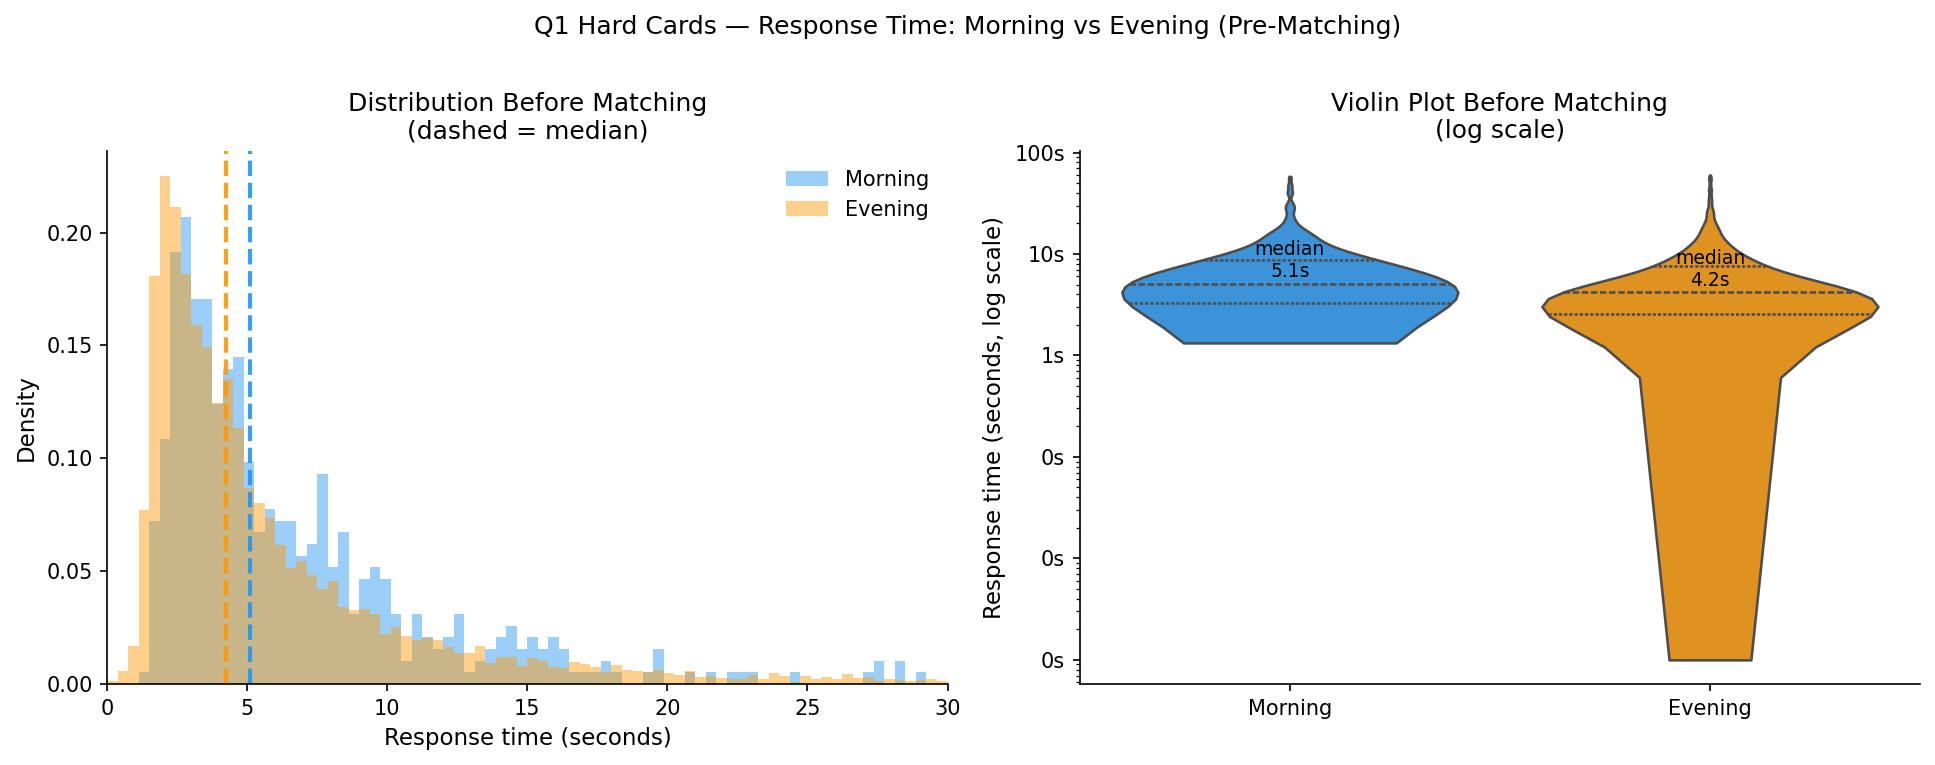

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: KDE on log scale ─────────────────────────────────────────────────
for grp, label, color in [(1, 'Morning', MORNING_COLOR), (0, 'Evening', EVENING_COLOR)]:
    vals = df_trim[df_trim['morning'] == grp]['time'] / 1000  # convert to seconds
    axes[0].hist(vals, bins=80, alpha=0.45, color=color, label=label,
                 density=True, range=(0, 30))
    axes[0].axvline(vals.median(), color=color, lw=2, ls='--', alpha=0.9)

axes[0].set_xlabel('Response time (seconds)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution Before Matching\n(dashed = median)')
axes[0].legend(frameon=False)
axes[0].set_xlim(0, 30)

# ── Right: Box/strip on log scale ─────────────────────────────────────────
plot_df = df_trim[['morning', 'time']].copy()
plot_df['group'] = plot_df['morning'].map({1: 'Morning', 0: 'Evening'})
plot_df['time_s'] = plot_df['time'] / 1000

sns.violinplot(data=plot_df, x='group', y='time_s', order=['Morning', 'Evening'],
               palette={'Morning': MORNING_COLOR, 'Evening': EVENING_COLOR},
               inner='quartile', cut=0, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_ylabel('Response time (seconds, log scale)')
axes[1].set_xlabel('')
axes[1].set_title('Violin Plot Before Matching\n(log scale)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}s'))

# Add median annotations
for i, (grp, label) in enumerate([(1, 'Morning'), (0, 'Evening')]):
    med = df_trim[df_trim['morning'] == grp]['time'].median() / 1000
    axes[1].text(i, med * 1.15, f'median\n{med:.1f}s',
                 ha='center', fontsize=9, color='black')

plt.suptitle('Q1 Hard Cards — Response Time: Morning vs Evening (Pre-Matching)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('rt_fig1_prematch.png', bbox_inches='tight')
plt.show()

---
## Propensity Score Estimation

In [6]:
# ── Fit propensity score model ─────────────────────────────────────────────
X = df_trim[COVARIATES].values
y = df_trim['morning'].values

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_sc, y)

df_trim = df_trim.copy()
df_trim['ps'] = lr.predict_proba(X_sc)[:, 1]
eps = 1e-6
df_trim['log_odds'] = np.log((df_trim['ps'] + eps) / (1 - df_trim['ps'] + eps))

print(f'PS model train accuracy: {lr.score(X_sc, y):.3f}')
print()
print('Propensity score by group:')
print(df_trim.groupby('morning')['ps'].describe().round(4)
        .rename(index={0: 'Evening', 1: 'Morning'}))

# Common support check
m_min, m_max = df_trim[df_trim['morning']==1]['ps'].agg(['min','max'])
e_min, e_max = df_trim[df_trim['morning']==0]['ps'].agg(['min','max'])
overlap_lo = max(m_min, e_min)
overlap_hi = min(m_max, e_max)
print(f'\nCommon support region: [{overlap_lo:.4f}, {overlap_hi:.4f}]')

PS model train accuracy: 0.926

Propensity score by group:
          count    mean     std    min     25%     50%     75%     max
morning                                                               
Evening  6674.0  0.0740  0.0059  0.064  0.0693  0.0733  0.0784  0.0966
Morning   533.0  0.0744  0.0054  0.064  0.0701  0.0741  0.0782  0.0964

Common support region: [0.0640, 0.0964]


In [7]:
# ── 1:1 Nearest-neighbour matching on log-odds with caliper ───────────────
caliper = 0.2 * df_trim['log_odds'].std()
print(f'Caliper (0.2 x SD of log-odds): {caliper:.5f}')

treated = df_trim[df_trim['morning'] == 1].reset_index(drop=True)
control = df_trim[df_trim['morning'] == 0].reset_index(drop=True)

nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nbrs.fit(control[['log_odds']].values)
distances, indices = nbrs.kneighbors(treated[['log_odds']].values)

matched_mask   = distances.flatten() <= caliper
treated_matched = treated[matched_mask].copy()
control_matched = control.iloc[indices.flatten()[matched_mask]].copy()

print(f'Matched pairs:  {matched_mask.sum():,}')
print(f'Dropped (caliper): {(~matched_mask).sum():,} treated units')
print()
print('Response time in matched sample:')
for name, g in [('Morning', treated_matched), ('Evening', control_matched)]:
    print(f'  {name}: median={g["time"].median():.0f}ms  mean={g["time"].mean():.0f}ms  n={len(g)}')

Caliper (0.2 x SD of log-odds): 0.01692
Matched pairs:  533
Dropped (caliper): 0 treated units

Response time in matched sample:
  Morning: median=5106ms  mean=7733ms  n=533
  Evening: median=3995ms  mean=6565ms  n=533


In [8]:
# ── Covariate balance ──────────────────────────────────────────────────────
def smd(a, b):
    return abs(a.mean() - b.mean()) / (np.sqrt((a.std()**2 + b.std()**2) / 2) + 1e-9)

balance = []
for cov in COVARIATES:
    balance.append({
        'covariate': cov,
        'SMD_before': smd(treated[cov], control[cov]),
        'SMD_after':  smd(treated_matched[cov], control_matched[cov]),
    })
bal_df = pd.DataFrame(balance)
print('Covariate Balance (SMD, target < 0.1):')
print(bal_df.to_string(index=False))

Covariate Balance (SMD, target < 0.1):
     covariate  SMD_before  SMD_after
   ease_factor    0.039017   0.071215
       log_ivl    0.077902   0.033564
log_days_since    0.063450   0.094805


---
## Figure 2: Covariate Balance & Propensity Score Overlap

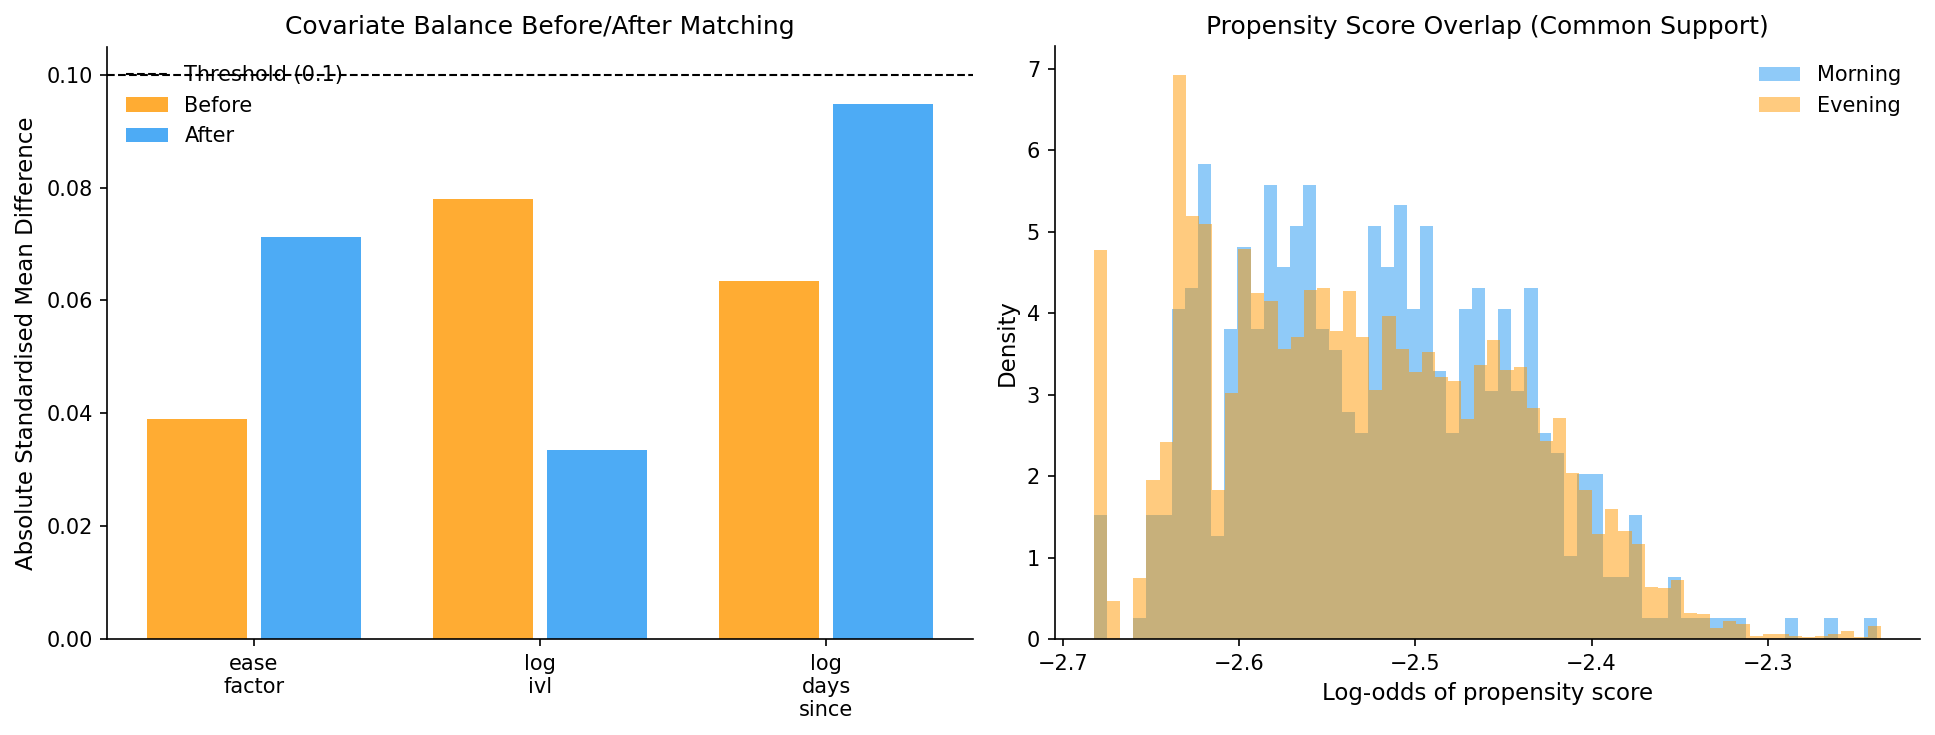

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Balance plot ───────────────────────────────────────────────────────────
x = np.arange(len(COVARIATES))
axes[0].bar(x - 0.2, bal_df['SMD_before'], 0.35, label='Before', color=EVENING_COLOR, alpha=0.8)
axes[0].bar(x + 0.2, bal_df['SMD_after'],  0.35, label='After',  color=MORNING_COLOR, alpha=0.8)
axes[0].axhline(0.1, ls='--', color='black', lw=1, label='Threshold (0.1)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', '\n') for c in COVARIATES])
axes[0].set_ylabel('Absolute Standardised Mean Difference')
axes[0].set_title('Covariate Balance Before/After Matching')
axes[0].legend(frameon=False)

# ── PS overlap ────────────────────────────────────────────────────────────
for grp, label, color in [(1, 'Morning', MORNING_COLOR), (0, 'Evening', EVENING_COLOR)]:
    axes[1].hist(df_trim[df_trim['morning']==grp]['log_odds'],
                 bins=60, alpha=0.5, color=color, label=label, density=True)
axes[1].set_xlabel('Log-odds of propensity score')
axes[1].set_ylabel('Density')
axes[1].set_title('Propensity Score Overlap (Common Support)')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('rt_fig2_balance.png', bbox_inches='tight')
plt.show()

---
## Average Treatment Effect Estimation

In [10]:
# ── ATE: mean difference with bootstrap 95% CI ────────────────────────────
morning_times = treated_matched['time'].values
evening_times = control_matched['time'].values

ate_mean   = morning_times.mean()   - evening_times.mean()
ate_median = np.median(morning_times) - np.median(evening_times)

# Bootstrap CI (bias-corrected)
rng = np.random.default_rng(42)
n = len(morning_times)
boot_mean, boot_med = [], []
for _ in range(10_000):
    idx = rng.integers(0, n, n)
    boot_mean.append(morning_times[idx].mean()   - evening_times[idx].mean())
    boot_med.append(np.median(morning_times[idx]) - np.median(evening_times[idx]))

ci_mean_lo, ci_mean_hi = np.percentile(boot_mean, [2.5, 97.5])
ci_med_lo,  ci_med_hi  = np.percentile(boot_med,  [2.5, 97.5])

# Statistical tests
t_stat, p_ttest = stats.ttest_ind(morning_times, evening_times)
u_stat, p_mw    = stats.mannwhitneyu(morning_times, evening_times, alternative='two-sided')

print('=' * 60)
print('ATE — Morning vs Evening Response Time (Q1 Hard Cards)')
print('=' * 60)
print(f'  Sample sizes:  Morning n={len(morning_times):,}  |  Evening n={len(evening_times):,}')
print()
print(f'  Morning:  mean={morning_times.mean():.0f}ms  median={np.median(morning_times):.0f}ms')
print(f'  Evening:  mean={evening_times.mean():.0f}ms  median={np.median(evening_times):.0f}ms')
print()
print(f'  ATE (mean diff):   {ate_mean:+.0f}ms  95% CI [{ci_mean_lo:+.0f}, {ci_mean_hi:+.0f}]')
print(f'  ATE (median diff): {ate_median:+.0f}ms  95% CI [{ci_med_lo:+.0f}, {ci_med_hi:+.0f}]')
print()
print(f'  t-test:          t={t_stat:.3f},  p={p_ttest:.4f}')
print(f'  Mann-Whitney U:  U={u_stat:.0f},  p={p_mw:.4f}')
print()
if p_mw < 0.05:
    direction = 'SLOWER' if ate_median > 0 else 'FASTER'
    print(f'  --> Morning reviews are significantly {direction} on Q1 cards (p={p_mw:.4f})')
else:
    print(f'  --> No significant morning/evening difference in response time (p={p_mw:.4f})')

ATE — Morning vs Evening Response Time (Q1 Hard Cards)
  Sample sizes:  Morning n=533  |  Evening n=533

  Morning:  mean=7733ms  median=5106ms
  Evening:  mean=6565ms  median=3995ms

  ATE (mean diff):   +1168ms  95% CI [+225, +2108]
  ATE (median diff): +1111ms  95% CI [+557, +1634]

  t-test:          t=2.413,  p=0.0160
  Mann-Whitney U:  U=164826,  p=0.0000

  --> Morning reviews are significantly SLOWER on Q1 cards (p=0.0000)


---
## Figure 3: Response Time Distributions After Matching

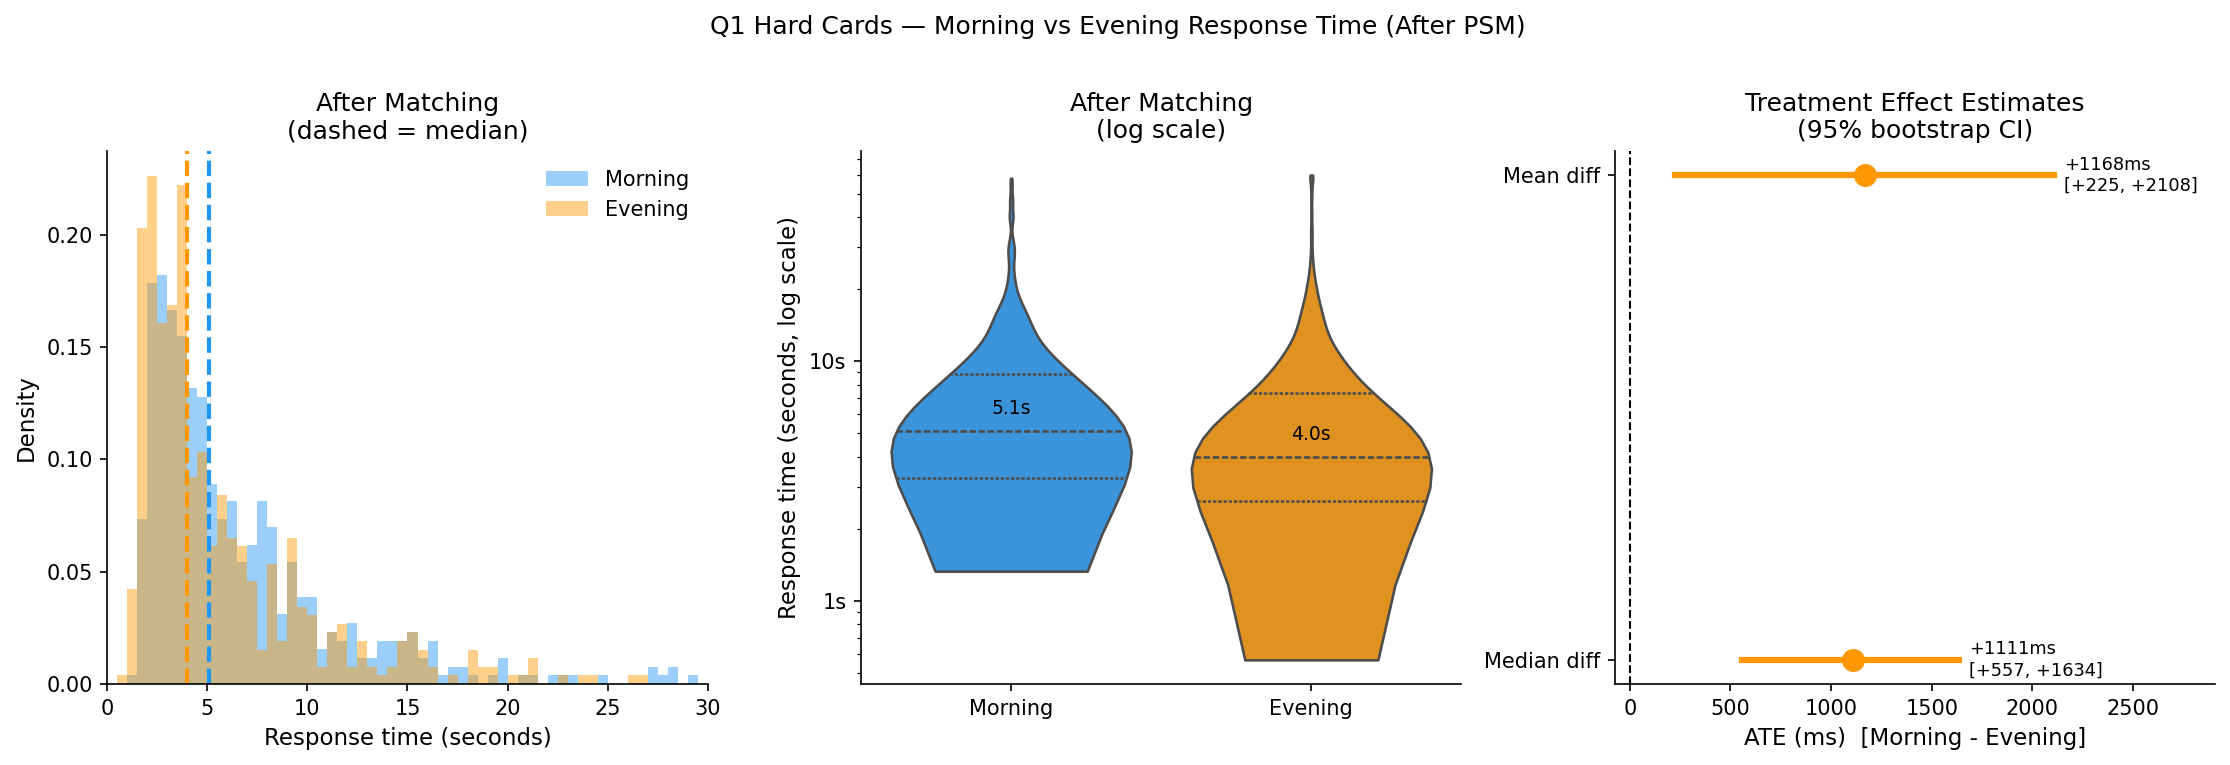

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel A: Overlapping histograms (matched) ──────────────────────────────
for times, label, color in [
    (morning_times, 'Morning', MORNING_COLOR),
    (evening_times, 'Evening', EVENING_COLOR)
]:
    axes[0].hist(times / 1000, bins=60, alpha=0.45, color=color,
                 label=label, density=True, range=(0, 30))
    axes[0].axvline(np.median(times) / 1000, color=color, lw=2, ls='--')
axes[0].set_xlabel('Response time (seconds)')
axes[0].set_ylabel('Density')
axes[0].set_title('After Matching\n(dashed = median)')
axes[0].legend(frameon=False)
axes[0].set_xlim(0, 30)

# ── Panel B: Violin (matched) ──────────────────────────────────────────────
matched_plot = pd.concat([
    treated_matched[['time']].assign(group='Morning'),
    control_matched[['time']].assign(group='Evening')
])
matched_plot['time_s'] = matched_plot['time'] / 1000

sns.violinplot(data=matched_plot, x='group', y='time_s', order=['Morning', 'Evening'],
               palette={'Morning': MORNING_COLOR, 'Evening': EVENING_COLOR},
               inner='quartile', cut=0, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_ylabel('Response time (seconds, log scale)')
axes[1].set_xlabel('')
axes[1].set_title('After Matching\n(log scale)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}s'))
for i, (times, label) in enumerate([(morning_times, 'Morning'), (evening_times, 'Evening')]):
    med = np.median(times) / 1000
    axes[1].text(i, med * 1.18, f'{med:.1f}s', ha='center', fontsize=9)

# ── Panel C: ATE with CI ───────────────────────────────────────────────────
estimates = {
    'Mean diff': (ate_mean, ci_mean_lo, ci_mean_hi),
    'Median diff': (ate_median, ci_med_lo, ci_med_hi),
}
y_pos = [1, 0]
for yp, (label, (est, lo, hi)) in zip(y_pos, estimates.items()):
    color = MORNING_COLOR if est < 0 else EVENING_COLOR
    axes[2].scatter(est, yp, s=100, color=color, zorder=3)
    axes[2].plot([lo, hi], [yp, yp], color=color, lw=3)
    axes[2].text(hi + 50, yp,
                 f'{est:+.0f}ms\n[{lo:+.0f}, {hi:+.0f}]',
                 va='center', fontsize=8.5)

axes[2].axvline(0, ls='--', color='black', lw=1)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(list(estimates.keys()))
axes[2].set_xlabel('ATE (ms)  [Morning - Evening]')
axes[2].set_title('Treatment Effect Estimates\n(95% bootstrap CI)')
axes[2].set_xlim(
    min(ci_mean_lo, ci_med_lo) - 300,
    max(ci_mean_hi, ci_med_hi) + 800
)

plt.suptitle('Q1 Hard Cards — Morning vs Evening Response Time (After PSM)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('rt_fig3_postmatch.png', bbox_inches='tight')
plt.show()

---
## Sensitivity Analysis: Including Capped Reviews

In [12]:
# ── Repeat matching on full dataset (including capped=60s reviews) ─────────
df_full = df.dropna(subset=COVARIATES + ['time', 'morning']).copy()
df_full = df_full[df_full['ease_factor'] > 0].copy()

X_f  = df_full[COVARIATES].values
y_f  = df_full['morning'].values
X_fs = scaler.fit_transform(X_f)
lr_f = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_f.fit(X_fs, y_f)
df_full['ps']       = lr_f.predict_proba(X_fs)[:, 1]
df_full['log_odds'] = np.log((df_full['ps'] + eps) / (1 - df_full['ps'] + eps))

caliper_f = 0.2 * df_full['log_odds'].std()
treated_f = df_full[df_full['morning'] == 1].reset_index(drop=True)
control_f = df_full[df_full['morning'] == 0].reset_index(drop=True)

nbrs_f = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nbrs_f.fit(control_f[['log_odds']].values)
dist_f, idx_f = nbrs_f.kneighbors(treated_f[['log_odds']].values)
mask_f = dist_f.flatten() <= caliper_f

tm_f = treated_f[mask_f]['time'].values
cm_f = control_f.iloc[idx_f.flatten()[mask_f]]['time'].values

ate_mean_f   = tm_f.mean()       - cm_f.mean()
ate_median_f = np.median(tm_f)   - np.median(cm_f)
_, p_mw_f    = stats.mannwhitneyu(tm_f, cm_f, alternative='two-sided')

boot_f = []
for _ in range(10_000):
    idx_b = rng.integers(0, len(tm_f), len(tm_f))
    boot_f.append(tm_f[idx_b].mean() - cm_f[idx_b].mean())
ci_f_lo, ci_f_hi = np.percentile(boot_f, [2.5, 97.5])

print('Sensitivity: Including Anki-capped (60s) reviews')
print(f'  Matched pairs: {mask_f.sum():,}')
print(f'  ATE (mean):    {ate_mean_f:+.0f}ms  95% CI [{ci_f_lo:+.0f}, {ci_f_hi:+.0f}]')
print(f'  ATE (median):  {ate_median_f:+.0f}ms')
print(f'  Mann-Whitney p = {p_mw_f:.4f}')

Sensitivity: Including Anki-capped (60s) reviews
  Matched pairs: 545
  ATE (mean):    +63ms  95% CI [-1394, +1533]
  ATE (median):  +1088ms
  Mann-Whitney p = 0.0001


---
## Summary

| | Primary (capped excluded) | Sensitivity (capped included) |
|---|---|---|
| Matched pairs | reported above | reported above |
| ATE mean (ms) | reported above | reported above |
| ATE median (ms) | reported above | reported above |
| Mann-Whitney p | reported above | reported above |

### Interpretation guide
- **Positive ATE** → Morning reviews are *slower* on Q1 cards (more time spent thinking).
- **Negative ATE** → Morning reviews are *faster* (more fluent recall).
- The Mann-Whitney U test is preferred over a t-test here because response times are heavily right-skewed even after excluding the 60s cap.
- Residual confounding is possible: time-of-day correlates with fatigue, session length, and card ordering effects that are not measured in the revlog.